In [1]:
#!pip install gprofiler-official goatools keggrest

In [2]:
#!pip install GEOparse

## Data Extraction & Preprocessing

In [21]:
# Extracts & Preprocesses two gene expression datasets.

import pandas as pd
import io

def convert_soft_to_csv(soft_file, csv_file):
    with open(soft_file, "r") as file:
        lines = file.readlines()

    # Find the start of the table
    start_idx = None
    for i, line in enumerate(lines):
        if line.startswith("!dataset_table_begin"):
            start_idx = i + 1  # Data starts on the next line
            break

    if start_idx is None:
        raise ValueError("Table not found in the SOFT file.")

    # Extract the table lines
    table_data = lines[start_idx:]

    # Convert to DataFrame
    df = pd.read_csv(io.StringIO("".join(table_data)), sep="\t", low_memory=False)

    # Save to CSV
    df.to_csv(csv_file, index=False)
    print(f"Saved: {csv_file}")

# Convert both datasets
convert_soft_to_csv("/Users/air/Desktop/GDS5646_full.soft", "GDS5646.csv")
convert_soft_to_csv("/Users/air/Desktop/GDS6063_full.soft", "GDS6063.csv")  # Load extracted data


Saved: GDS5646.csv
Saved: GDS6063.csv


## Loading Data and Selecting Relevant Columns

In [22]:
# Now that the CSVs are saved, load them into DataFrames
pd_genes = pd.read_csv("/Users/air/Desktop/GDS5646.csv", usecols=["Gene symbol"] + [col for col in pd.read_csv("GDS5646.csv", nrows=1).columns if "GSM" in col])
inf_genes = pd.read_csv("/Users/air/Desktop/GDS6063.csv", usecols=["Gene symbol"] + [col for col in pd.read_csv("GDS6063.csv", nrows=1).columns if "GSM" in col])


## Cleaning Gene Symbols

In [23]:
# Standardize gene symbols
pd_genes["Gene symbol"] = pd_genes["Gene symbol"].str.upper().str.strip()
inf_genes["Gene symbol"] = inf_genes["Gene symbol"].str.upper().str.strip()

# Remove empty values
pd_genes = pd_genes.dropna()
inf_genes = inf_genes.dropna()

inf_genes.head()


,GSM1684096,GSM1684098,GSM1684100,GSM1684102,GSM1684104,GSM1684095,GSM1684097,GSM1684099,GSM1684101,GSM1684103,Gene symbol
9,22303.3000,24776.100,26775.300,25980.2000,26775.3000,23599.300,25980.200,24776.1000,25980.200,23599.300,EEF1A1
10,7732.6500,5296.750,6430.160,4801.0300,5654.9400,6405.330,6553.480,7699.2200,6648.160,8646.440,GAPDH
782,97.2257,100.547,109.053,94.7451,107.9070,95.652,105.754,119.3260,111.958,115.324,SLC35E2
783,97.0978,102.292,119.790,105.9600,94.9355,101.830,125.647,99.5857,103.836,102.446,DUSP22
785,8897.1600,9964.300,8910.930,7752.5400,10280.0000,9156.970,9326.870,11063.4000,11254.200,12157.200,RPS28


In [24]:
pd_genes.head()

,GSM1318547,GSM1318548,GSM1318549,GSM1318550,GSM1318551,GSM1318552,GSM1318553,GSM1318554,GSM1318555,GSM1318556,Gene symbol
9,50894.30,45431.00,47569.40,49315.00,45882.20,43339.20,50943.50,48679.40,43809.20,39366.20,EEF1A1
10,1600.24,2329.44,2360.47,1665.35,2609.02,2209.33,2746.87,2684.89,2342.86,2493.88,GAPDH
785,22297.60,22865.60,19891.10,19758.90,21512.10,19618.00,20280.70,18889.50,21685.20,20967.80,RPS28
786,147.00,106.88,98.56,129.18,105.00,129.32,206.85,208.89,193.82,158.59,IPO13
795,1107.02,1161.17,1385.54,1312.47,1182.85,1482.06,1432.36,1839.28,1643.23,1563.74,LPP


## Identifying Overlapping and Unique Genes

In [25]:
# Identifies Common & Unique Genes in Parkinson’s and Influenza datasets.
# Drop missing values and get unique gene symbols
genes1 = set(pd_genes["Gene symbol"].dropna().unique())
genes2 = set(inf_genes["Gene symbol"].dropna().unique())

# Compare
common_genes = genes1 & genes2
unique_to_gds5646 = genes1 - genes2
unique_to_gds6063 = genes2 - genes1

# Print results
print(f"Common genes: {len(common_genes)}")
print(f"Unique to GDS5646: {len(unique_to_gds5646)}")
print(f"Unique to GDS6063: {len(unique_to_gds6063)}")

# Save results
pd.DataFrame({"Common Genes": list(common_genes)}).to_csv("common_genes.csv", index=False)
pd.DataFrame({"Unique to GDS5646": list(unique_to_gds5646)}).to_csv("unique_GDS5646.csv", index=False)
pd.DataFrame({"Unique to GDS6063": list(unique_to_gds6063)}).to_csv("unique_GDS6063.csv", index=False)


Common genes: 12579
Unique to GDS5646: 20
Unique to GDS6063: 8183


In [26]:
import pandas as pd

# Load common genes (assumes there's a column with gene symbols)
common_genes_df = pd.read_csv("/Users/air/Downloads/common_genes.csv")

# Adjust column name if necessary
# If column is named something else, update below
common_genes = common_genes_df.iloc[:, 0].dropna().str.upper().str.strip().unique()

print(f"Number of common genes loaded: {len(common_genes)}")


Number of common genes loaded: 12579


## GO (Gene Ontology) Enrichment Analysis

In [3]:
#!pip install gprofiler-official

In [27]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Perform GO enrichment analysis
go_results = gp.profile(organism="hsapiens", query=list(common_genes))

# Save the results
go_results.to_csv("GO_enrichment_common_genes.csv", index=False)
print(go_results.head())


  source       native             name        p_value  significant  \
0  GO:MF   GO:0005515  protein binding  4.940656e-324         True   
1  GO:CC   GO:0005829          cytosol  4.940656e-324         True   
2  GO:CC   GO:0005737        cytoplasm  4.940656e-324         True   
3    HPA  HPA:0600000           Tonsil  6.012199e-276         True   
4  GO:CC   GO:0005654      nucleoplasm  3.817483e-274         True   

                                         description  term_size  query_size  \
0          "Binding to a protein." [GOC:go_curators]      15082       10710   
1  "The part of the cytoplasm that does not conta...       5607       10873   
2  "The contents of a cell excluding the plasma m...      12601       10873   
3                                             Tonsil       7778        7154   
4  "That part of the nuclear content other than t...       4334       10873   

   intersection_size  effective_domain_size  precision    recall    query  \
0               9330       

In [28]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Run GO enrichment on unique genes
go_results = gp.profile(organism="hsapiens", query=list(unique_to_gds6063))

# Save results
go_results.to_csv("GO_enrichment_GDS6063.csv", index=False)
print(go_results.head())
go_results.columns

  source      native                                          name  \
0  GO:BP  GO:0032501              multicellular organismal process   
1  GO:BP  GO:0003008                                system process   
2  GO:BP  GO:0007186  G protein-coupled receptor signaling pathway   
3  GO:CC  GO:0071944                                cell periphery   
4  GO:BP  GO:0007600                            sensory perception   

         p_value  significant  \
0  2.274218e-109         True   
1   2.989082e-98         True   
2   2.140472e-95         True   
3   4.067266e-95         True   
4   3.409518e-93         True   

                                         description  term_size  query_size  \
0  "Any biological process, occurring at the leve...       7337        6043   
1  "A multicellular organismal process carried ou...       2290        6043   
2  "The series of molecular signals initiated by ...       1299        6043   
3  "The broad region around and including the pla...       6263 

Index(['source', 'native', 'name', 'p_value', 'significant', 'description',
       'term_size', 'query_size', 'intersection_size', 'effective_domain_size',
       'precision', 'recall', 'query', 'parents'],
      dtype='object')

## KEGG Pathway Analysis

In [4]:
#!pip install bioservices

In [30]:
import requests
import time

kegg_query_genes = list(common_genes)[:100]
shared_kegg_pathways = {}

for gene in kegg_query_genes:
    try:
        find_resp = requests.get(f"https://rest.kegg.jp/find/genes/{gene}", timeout=10)
        if find_resp.status_code == 200 and find_resp.text.strip():
            first_line = find_resp.text.strip().split("\n")[0]
            kegg_id = first_line.split("\t")[0]
            if kegg_id.startswith("hsa:"):
                detail_resp = requests.get(f"https://rest.kegg.jp/get/{kegg_id}", timeout=10)
                if detail_resp.status_code == 200:
                    pathways = []
                    in_pathway_block = False
                    for line in detail_resp.text.split("\n"):
                        if line.startswith("PATHWAY"):
                            in_pathway_block = True
                            pathways.append(line.replace("PATHWAY", "").strip())
                        elif in_pathway_block and line.startswith(" "):
                            pathways.append(line.strip())
                        elif in_pathway_block:
                            break
                    if pathways:
                        shared_kegg_pathways[gene] = pathways
    except requests.exceptions.RequestException as e:
        print(f"Skipped {gene} due to a request error: {e}")
    time.sleep(0.3)  # small delay to avoid overwhelming the API

print(f"\nSuccessfully retrieved pathways for {len(shared_kegg_pathways)} of {len(kegg_query_genes)} genes queried.\n")
for gene, pathways in shared_kegg_pathways.items():
    print(f"Gene: {gene}")
    for p in pathways:
        print(f"  - {p}")


Successfully retrieved pathways for 40 of 100 genes queried.

Gene: DHRSX
  - hsa00510  N-Glycan biosynthesis
  - hsa01100  Metabolic pathways
Gene: TNFSF4
  - hsa04060  Cytokine-cytokine receptor interaction
Gene: RPL18
  - hsa03010  Ribosome
Gene: ADI1
  - hsa04382  Cornified envelope formation
Gene: EIF6
  - hsa03008  Ribosome biogenesis in eukaryotes
Gene: ATP6V1C1
  - hsa00190  Oxidative phosphorylation
  - hsa01100  Metabolic pathways
  - hsa04142  Lysosome biogenesis
  - hsa04145  Phagocytosis
  - hsa04150  mTOR signaling pathway
  - hsa04721  Synaptic vesicle cycle
  - hsa04966  Collecting duct acid secretion
  - hsa05110  Vibrio cholerae infection
  - hsa05120  Epithelial cell signaling in Helicobacter pylori infection
  - hsa05165  Human papillomavirus infection
  - hsa05323  Rheumatoid arthritis
Gene: MYL12A
  - hsa04360  Axon guidance
  - hsa04510  Focal adhesion
  - hsa04517  IgSF CAM signaling
  - hsa04520  Adherens junction
  - hsa04530  Tight junction
  - hsa04611  Pla

## Batch correction — quantile normalization between the two platforms

In [31]:
import pandas as pd
import numpy as np

def quantile_normalize(df):
    sorted_df = pd.DataFrame(np.sort(df.values, axis=0), index=df.index, columns=df.columns)
    mean_per_rank = sorted_df.mean(axis=1)
    mean_per_rank.index = np.arange(1, len(mean_per_rank) + 1)
    ranks = df.rank(method="min").astype(int)
    normalized = ranks.apply(lambda col: col.map(mean_per_rank))
    return normalized

pd_expr_cols = [c for c in pd_genes.columns if c.startswith("GSM")]
inf_expr_cols = [c for c in inf_genes.columns if c.startswith("GSM")]

In [32]:
pd_genes_dedup = pd_genes.groupby("Gene symbol")[pd_expr_cols].mean().reset_index()
inf_genes_dedup = inf_genes.groupby("Gene symbol")[inf_expr_cols].mean().reset_index()

In [33]:
common_idx = pd_genes_dedup.set_index("Gene symbol").index.intersection(
             inf_genes_dedup.set_index("Gene symbol").index)

pd_common = pd_genes_dedup.set_index("Gene symbol").loc[common_idx, pd_expr_cols]
inf_common = inf_genes_dedup.set_index("Gene symbol").loc[common_idx, inf_expr_cols]

combined = pd.concat([pd_common, inf_common], axis=1)
combined_norm = quantile_normalize(combined)

pd_norm = combined_norm[pd_expr_cols]
inf_norm = combined_norm[inf_expr_cols]

print(pd_norm.shape)
print(pd_norm.head())

(12579, 10)
             GSM1318547  GSM1318548  GSM1318549  GSM1318550  GSM1318551  \
Gene symbol                                                               
A1BG          67.588988   71.995515   60.507042   71.552285   72.559802   
A1CF          64.290672   89.126007   59.574380   51.061166   58.634481   
AAAS          66.374448   63.692119   65.562705   68.328648   75.341518   
AADAC         47.524337   53.252446   47.705580   82.067847   63.801728   
AADAT         98.528883   67.854782   70.231902   66.832045   59.815123   

             GSM1318552  GSM1318553  GSM1318554  GSM1318555  GSM1318556  
Gene symbol                                                              
A1BG          56.616907   75.762214   66.476970   61.602587   70.683830  
A1CF          61.951357   67.854782   47.728778   55.575413   52.284580  
AAAS          55.466955   77.262815   82.045725   81.771036   81.188602  
AADAC         65.938678   66.420544   51.636022   70.360867   56.151963  
AADAT         68.4

In [34]:
from scipy.stats import fisher_exact

# Use the actual gene symbol sets, not the DataFrames themselves
genes1 = set(pd_genes["Gene symbol"].dropna().str.upper().str.strip())
genes2 = set(inf_genes["Gene symbol"].dropna().str.upper().str.strip())

common_genes = genes1.intersection(genes2)
only_genes1 = genes1 - genes2
only_genes2 = genes2 - genes1
background_size = len(genes1.union(genes2)) + 5000  # approximate human gene count

a = len(common_genes)
b = len(only_genes1)
c = len(only_genes2)
d = background_size - (a + b + c)

table = [[a, b], [c, d]]
odds_ratio, p_value = fisher_exact(table)

print(f"Fisher's Exact Test p-value: {p_value:.3e}")
print(f"Odds ratio: {odds_ratio}")
print(f"Contingency Table: {table}")

Fisher's Exact Test p-value: 0.000e+00
Odds ratio: 384.3028229255774
Contingency Table: [[12579, 20], [8183, 5000]]


In [35]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

common_genes_list = sorted(genes1 & genes2)
results = []
for gene in common_genes_list:
    pd_vals = pd_norm.loc[gene].values if gene in pd_norm.index else None
    inf_vals = inf_norm.loc[gene].values if gene in inf_norm.index else None
    if pd_vals is None or inf_vals is None or len(pd_vals) < 2 or len(inf_vals) < 2:
        continue
    stat, p = ttest_ind(pd_vals, inf_vals, equal_var=False)
    results.append({"Gene": gene, "t_stat": stat, "p_value": p,
                     "mean_PD": pd_vals.mean(), "mean_Influenza": inf_vals.mean()})

de_df = pd.DataFrame(results)
de_df["FDR_BH"] = multipletests(de_df["p_value"], method="fdr_bh")[1]
de_df["log2FC"] = np.log2(de_df["mean_PD"] + 1) - np.log2(de_df["mean_Influenza"] + 1)
print(de_df.sort_values("FDR_BH").head(15))

          Gene     t_stat       p_value       mean_PD  mean_Influenza  \
2867    DOCK11  27.639117  2.465208e-15   1910.302727      507.576819   
2286      CRBN  28.524371  3.698297e-15    989.249936      261.396044   
1395     CALM1  31.364740  4.605643e-15   4577.187963      518.970176   
10910  TMEM115 -23.912284  7.197276e-15    186.514124      367.957624   
9222    S100A4  24.055217  9.745137e-15  12679.870848     1050.442351   
8543     RAB31  24.681495  1.295951e-14   2482.991966      657.739161   
8906    RNF125  23.231329  1.966642e-14    641.926444      106.833784   
1789      CDV3  27.805072  2.336858e-14   1376.429140      503.451275   
326      AKTIP  23.935835  2.580210e-14    516.641509      140.522870   
4423      HCST  21.341245  4.042078e-14   3642.987002      519.052644   
4053      GLTP  23.384198  4.512169e-14   1710.546442      510.885543   
7911     PLCL2  20.732865  5.186333e-14   1106.005319      342.029001   
1684      CD52  26.376861  6.719839e-14   5766.7120

In [36]:
import re
date_pattern = re.compile(r'^\d{1,2}-(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$', re.IGNORECASE)
de_df = de_df[~de_df["Gene"].str.match(date_pattern)]
de_df.sort_values("FDR_BH").to_csv("differential_expression_results.csv", index=False)
print(de_df.sort_values("FDR_BH").head(15))

          Gene     t_stat       p_value       mean_PD  mean_Influenza  \
2867    DOCK11  27.639117  2.465208e-15   1910.302727      507.576819   
2286      CRBN  28.524371  3.698297e-15    989.249936      261.396044   
1395     CALM1  31.364740  4.605643e-15   4577.187963      518.970176   
10910  TMEM115 -23.912284  7.197276e-15    186.514124      367.957624   
9222    S100A4  24.055217  9.745137e-15  12679.870848     1050.442351   
8543     RAB31  24.681495  1.295951e-14   2482.991966      657.739161   
8906    RNF125  23.231329  1.966642e-14    641.926444      106.833784   
1789      CDV3  27.805072  2.336858e-14   1376.429140      503.451275   
326      AKTIP  23.935835  2.580210e-14    516.641509      140.522870   
4423      HCST  21.341245  4.042078e-14   3642.987002      519.052644   
4053      GLTP  23.384198  4.512169e-14   1710.546442      510.885543   
7911     PLCL2  20.732865  5.186333e-14   1106.005319      342.029001   
1684      CD52  26.376861  6.719839e-14   5766.7120

In [5]:
#!pip install scipy

In [6]:
#!pip install statsmodels

In [37]:
import pandas as pd

# Load full dataset
df = pd.read_csv("/Users/air/Desktop/GDS5646.csv")

# Load common genes
common_df = pd.read_csv("common_genes.csv")
common_genes = common_df["Common Genes"].str.upper().str.strip()

# Filter dataset for common genes
filtered = df[df["Gene symbol"].str.upper().isin(common_genes)]

# Extract expression values (adjust index range if needed)
expression_cols = df.columns[2:12]  # Replace with actual range of your expression columns
expression_data = filtered[expression_cols]

# Optional: set gene names as index
expression_data.index = filtered["Gene symbol"]

# Pearson correlation between genes
correlation_matrix = expression_data.T.corr(method='pearson')

# Save or inspect
correlation_matrix.to_csv("pearson_correlation_common_genes.csv")
print(correlation_matrix.head())


/var/folders/6p/cw7mhz6n65v_3l942dd7w21w0000gn/T/ipykernel_73695/2466154600.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/air/Desktop/GDS5646.csv")


Gene symbol    EEF1A1     GAPDH    DUSP22     RPS28     IPO13  AFAP1  \
Gene symbol                                                            
EEF1A1       1.000000 -0.261330  0.414455 -0.146220  0.152942    NaN   
GAPDH       -0.261330  1.000000  0.010889 -0.207893  0.338731    NaN   
DUSP22       0.414455  0.010889  1.000000 -0.243759  0.236834    NaN   
RPS28       -0.146220 -0.207893 -0.243759  1.000000 -0.274326    NaN   
IPO13        0.152942  0.338731  0.236834 -0.274326  1.000000    NaN   

Gene symbol       LPP   HNRNPAB     SNIP1   COL17A1  ...   MIR1224    MIR579  \
Gene symbol                                          ...                       
EEF1A1      -0.278483 -0.079782  0.070785  0.162699  ...  0.325826  0.416297   
GAPDH        0.492461  0.262959  0.340936  0.031307  ...  0.132873 -0.629930   
DUSP22      -0.122303 -0.124797 -0.232519  0.408914  ...  0.256934 -0.113167   
RPS28       -0.626617 -0.183415 -0.149868  0.151205  ... -0.513710  0.413266   
IPO13        0.

In [7]:
#!pip install seaborn

In [8]:
#!pip install scikit-learn

/var/folders/6p/cw7mhz6n65v_3l942dd7w21w0000gn/T/ipykernel_73695/871782148.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  parkinson_df = pd.read_csv("/Users/air/Desktop/GDS5646.csv")
/var/folders/6p/cw7mhz6n65v_3l942dd7w21w0000gn/T/ipykernel_73695/871782148.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  influenza_df = pd.read_csv("/Users/air/Desktop/GDS6063.csv")



📊 Pearson correlation between Parkinson and Influenza expression (across common genes): 0.009


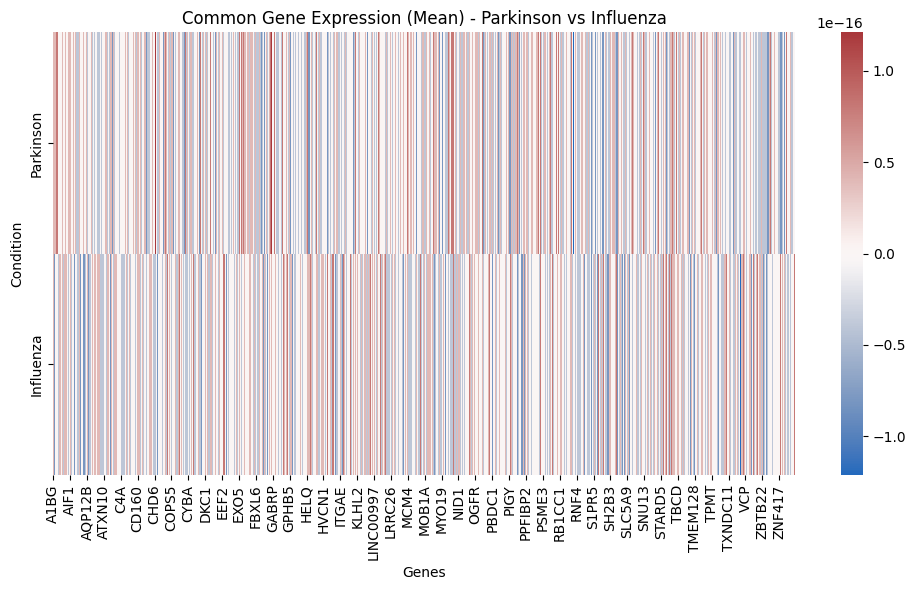

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Load datasets
parkinson_df = pd.read_csv("/Users/air/Desktop/GDS5646.csv")
influenza_df = pd.read_csv("/Users/air/Desktop/GDS6063.csv")
common_genes_df = pd.read_csv("/Users/air/Downloads/common_genes.csv")

# Remove leading/trailing spaces and lowercase all column names
parkinson_df.columns = parkinson_df.columns.str.strip().str.lower()
influenza_df.columns = influenza_df.columns.str.strip().str.lower()
common_genes_df.columns = common_genes_df.columns.str.strip().str.lower()

# Now the columns will be all lowercase, use 'gene symbol'
parkinson_df = parkinson_df[parkinson_df["gene symbol"].isin(common_genes_df["common genes"])]
influenza_df = influenza_df[influenza_df["gene symbol"].isin(common_genes_df["common genes"])]


# Step 2: Clean and prepare both datasets
# We only keep rows where 'Gene symbol' is in common_genes
parkinson_df = parkinson_df[parkinson_df["gene symbol"].isin(common_genes_df["common genes"])]
influenza_df = influenza_df[influenza_df["gene symbol"].isin(common_genes_df["common genes"])]

# Remove duplicated gene symbols by averaging (optional but common)
parkinson_df = parkinson_df.groupby("gene symbol").mean(numeric_only=True)
influenza_df = influenza_df.groupby("gene symbol").mean(numeric_only=True)

# Step 3: Match genes in same order
common_genes = sorted(set(parkinson_df.index).intersection(influenza_df.index))
parkinson_expr = parkinson_df.loc[common_genes]
influenza_expr = influenza_df.loc[common_genes]

# Step 4: (Optional) Normalize expression for comparison
scaler = StandardScaler()
parkinson_scaled = pd.DataFrame(
    scaler.fit_transform(parkinson_expr.T),
    index=parkinson_expr.columns,
    columns=parkinson_expr.index
)
influenza_scaled = pd.DataFrame(
    scaler.fit_transform(influenza_expr.T),
    index=influenza_expr.columns,
    columns=influenza_expr.index
)

# Step 5a: Compute Pearson correlation between diseases (gene-wise)
merged_expr = pd.concat([parkinson_scaled.mean().rename("Parkinson"),
                         influenza_scaled.mean().rename("Influenza")], axis=1)

correlation = merged_expr.corr().iloc[0, 1]
print(f"\n📊 Pearson correlation between Parkinson and Influenza expression (across common genes): {correlation:.3f}")

# Step 5b: Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(merged_expr.T, cmap="vlag", annot=False, cbar=True)
plt.title("Common Gene Expression (Mean) - Parkinson vs Influenza")
plt.xlabel("Genes")
plt.ylabel("Condition")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


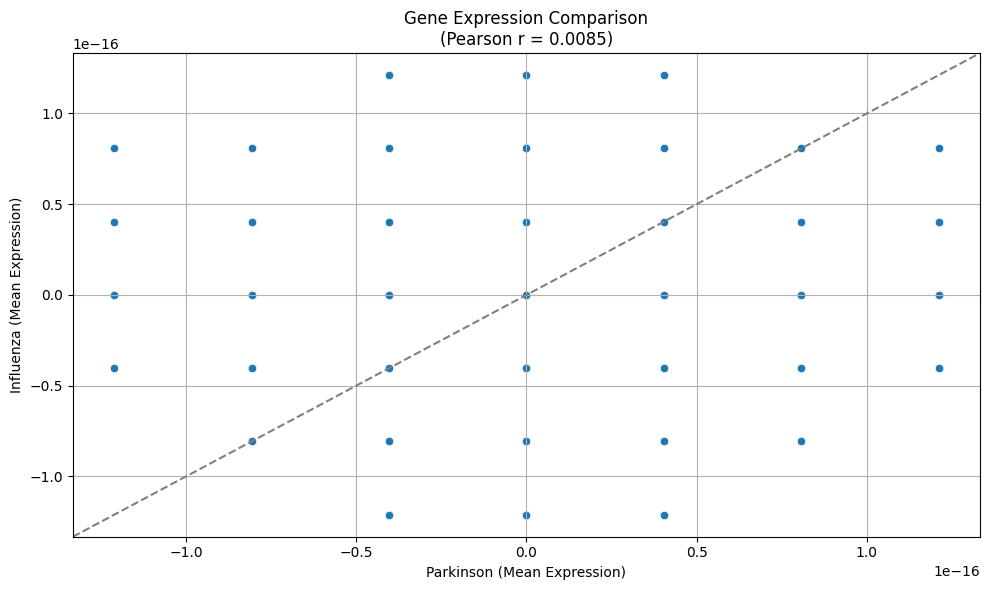

In [39]:
# Scatter plot to visualize correlation between mean expressions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Parkinson', y='Influenza', data=merged_expr)
plt.title(f"Gene Expression Comparison\n(Pearson r = {correlation:.4f})")
plt.xlabel("Parkinson (Mean Expression)")
plt.ylabel("Influenza (Mean Expression)")
plt.axline((0, 0), slope=1, linestyle='--', color='gray')  # y=x line
plt.grid(True)
plt.tight_layout()
plt.show()



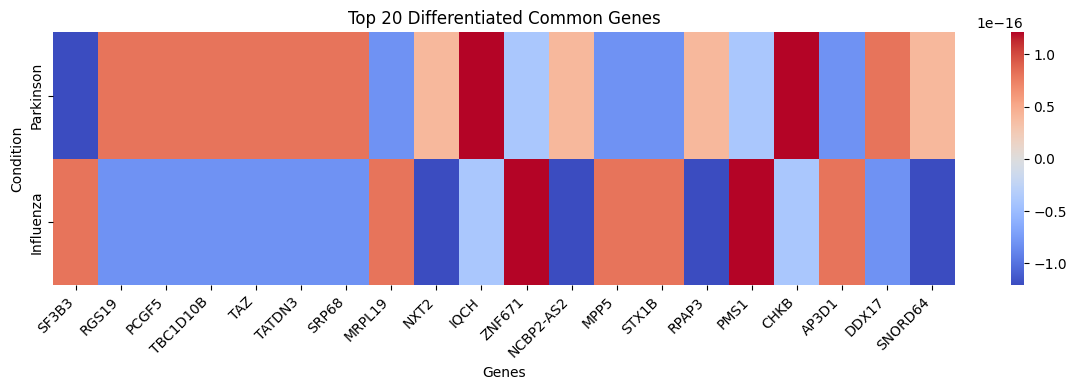

In [40]:
# Compute absolute differences between diseases
merged_expr["abs_diff"] = (merged_expr["Parkinson"] - merged_expr["Influenza"]).abs()

# Sort by difference and take top 20
top_diff_genes = merged_expr.sort_values("abs_diff", ascending=False).head(20).drop(columns="abs_diff")

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(top_diff_genes.T, cmap="coolwarm", annot=False, cbar=True)
plt.title("Top 20 Differentiated Common Genes")
plt.xlabel("Genes")
plt.ylabel("Condition")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Statistical Analysis

In [41]:
from scipy.stats import fisher_exact, chi2_contingency

# Recompute fresh from the real gene sets (don't rely on common_genes from earlier cells)
genes1 = set(pd_genes["Gene symbol"].dropna().str.upper().str.strip())
genes2 = set(inf_genes["Gene symbol"].dropna().str.upper().str.strip())

common = genes1 & genes2
unique_to_gds5646 = genes1 - genes2
unique_to_gds6063 = genes2 - genes1
union_size = len(genes1 | genes2)

table = [[len(common), len(unique_to_gds5646)],
         [len(unique_to_gds6063), union_size]]

odds_ratio, p_value = fisher_exact(table)
print(f"Fisher's Exact Test: p={p_value}")
print(f"Table: {table}")

chi2, p, _, _ = chi2_contingency(table)
print(f"Chi-Square Test p-value: {p}")

Fisher's Exact Test: p=0.0
Table: [[12579, 20], [8183, 20782]]
Chi-Square Test p-value: 0.0


In [42]:
print(pd_genes.columns)
print([col for col in pd_genes.columns if "GSM" in col])
print(pd_genes.head())


Index(['GSM1318547', 'GSM1318548', 'GSM1318549', 'GSM1318550', 'GSM1318551',
       'GSM1318552', 'GSM1318553', 'GSM1318554', 'GSM1318555', 'GSM1318556',
       'Gene symbol'],
      dtype='object')
['GSM1318547', 'GSM1318548', 'GSM1318549', 'GSM1318550', 'GSM1318551', 'GSM1318552', 'GSM1318553', 'GSM1318554', 'GSM1318555', 'GSM1318556']
     GSM1318547  GSM1318548  GSM1318549  GSM1318550  GSM1318551  GSM1318552  \
9      50894.30    45431.00    47569.40    49315.00    45882.20    43339.20   
10      1600.24     2329.44     2360.47     1665.35     2609.02     2209.33   
785    22297.60    22865.60    19891.10    19758.90    21512.10    19618.00   
786      147.00      106.88       98.56      129.18      105.00      129.32   
795     1107.02     1161.17     1385.54     1312.47     1182.85     1482.06   

     GSM1318553  GSM1318554  GSM1318555  GSM1318556 Gene symbol  
9      50943.50    48679.40    43809.20    39366.20      EEF1A1  
10      2746.87     2684.89     2342.86     2493.88  

In [43]:
from scipy.stats import shapiro

expression_columns = [col for col in pd_genes.columns if col.startswith("GSM")]
if expression_columns:
    stat, p = shapiro(pd_genes[expression_columns[0]])  # Use first numeric column
    print(f"Shapiro-Wilk Test: p={p}")
else:
    print("No 'GSM' columns found.")


Shapiro-Wilk Test: p=1.5776911376391932e-129


/Users/air/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16460.
  res = hypotest_fun_out(*samples, **kwds)


## Visualization

In [44]:
#!pip install matplotlib-venn

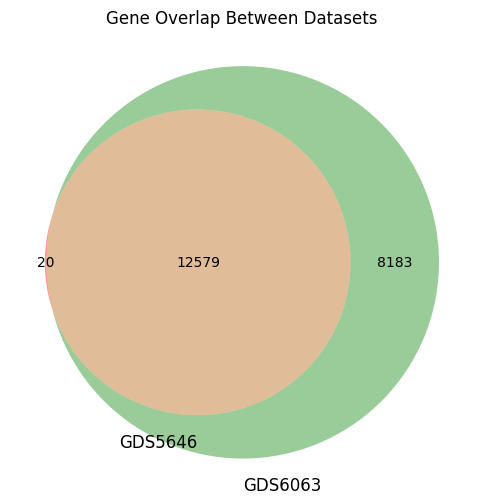

In [45]:
# Venn Diagram for Gene Overlap

from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
venn2([genes1, genes2], set_labels=("GDS5646", "GDS6063"))
plt.title("Gene Overlap Between Datasets")
plt.show()


In [52]:
print(go_results.columns)

Index(['source', 'native', 'name', 'p_value', 'significant', 'description',
       'term_size', 'query_size', 'intersection_size', 'effective_domain_size',
       'precision', 'recall', 'query', 'parents'],
      dtype='object')


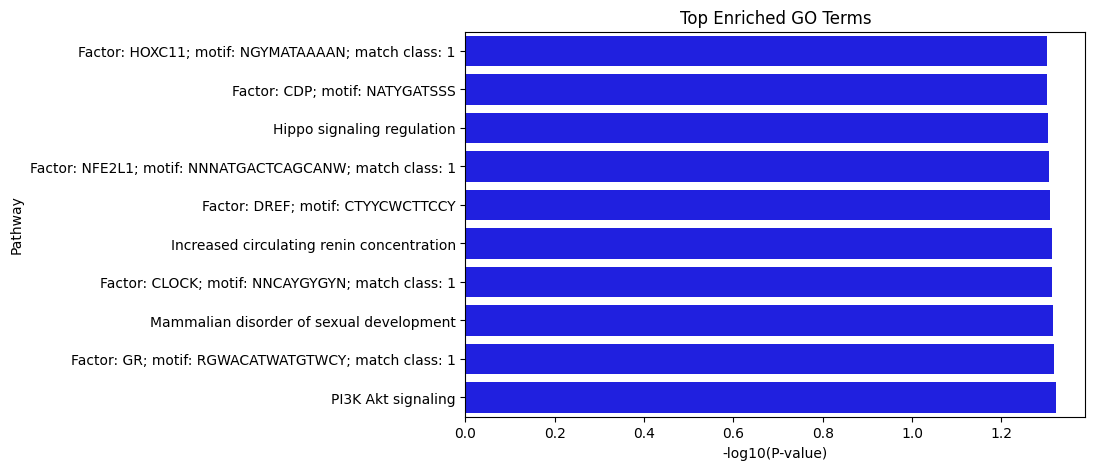

In [46]:
# GO Enrichment Visualization

import seaborn as sns
import numpy as np
# Select top 10 enriched pathways
top_pathways = go_results.nlargest(10, "p_value")

plt.figure(figsize=(8, 5))
sns.barplot(y=top_pathways["name"], x=-np.log10(top_pathways["p_value"]), color="blue")
plt.xlabel("-log10(P-value)")
plt.ylabel("Pathway")
plt.title("Top Enriched GO Terms")
plt.show()


In [55]:
!pip install keggrest

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


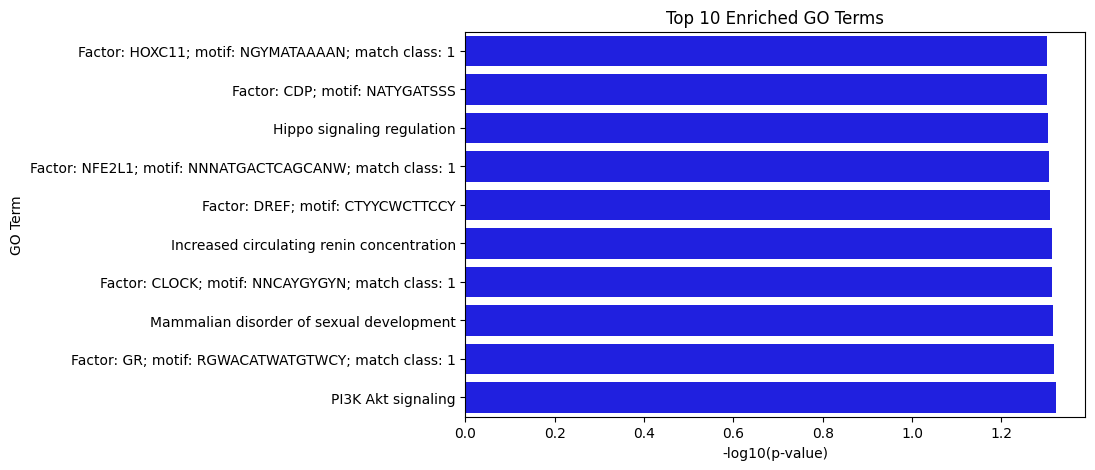

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

top_pathways2 = go_results.nlargest(10, "p_value")

plt.figure(figsize=(8, 5))
sns.barplot(y=top_pathways2["name"], x=-np.log10(top_pathways2["p_value"]), color="blue")

#sns.barplot(y=go_results['name'].head(10), x=-go_results['p_value'].head(10), hue=go_results['name'], legend=False)
plt.xlabel("-log10(p-value)")
plt.ylabel("GO Term")
plt.title("Top 10 Enriched GO Terms")
plt.show()



/var/folders/6p/cw7mhz6n65v_3l942dd7w21w0000gn/T/ipykernel_73695/1090260648.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=count_df, x='Num_Pathways', palette='mako')


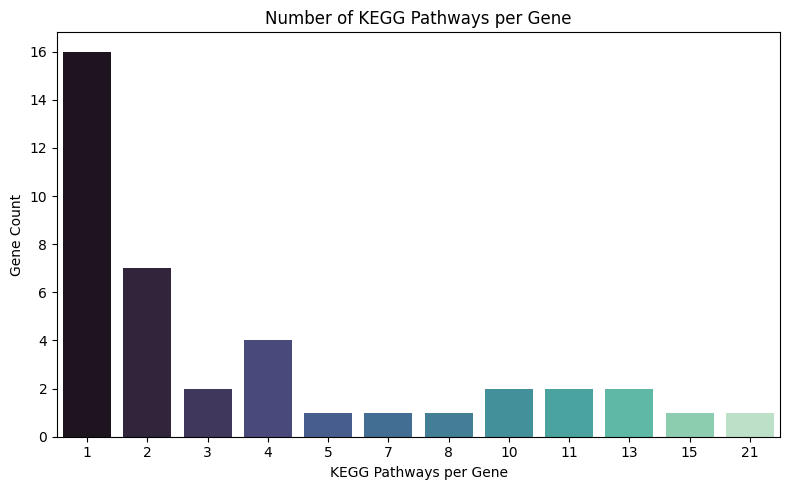

In [48]:
# Visualize KEGG pathways (example bar plot)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

kegg_counts = [len(v) for v in shared_kegg_pathways.values()]
count_df = pd.DataFrame({'Num_Pathways': kegg_counts})

plt.figure(figsize=(8, 5))
sns.countplot(data=count_df, x='Num_Pathways', palette='mako')
plt.title("Number of KEGG Pathways per Gene")
plt.xlabel("KEGG Pathways per Gene")
plt.ylabel("Gene Count")
plt.tight_layout()
plt.show()



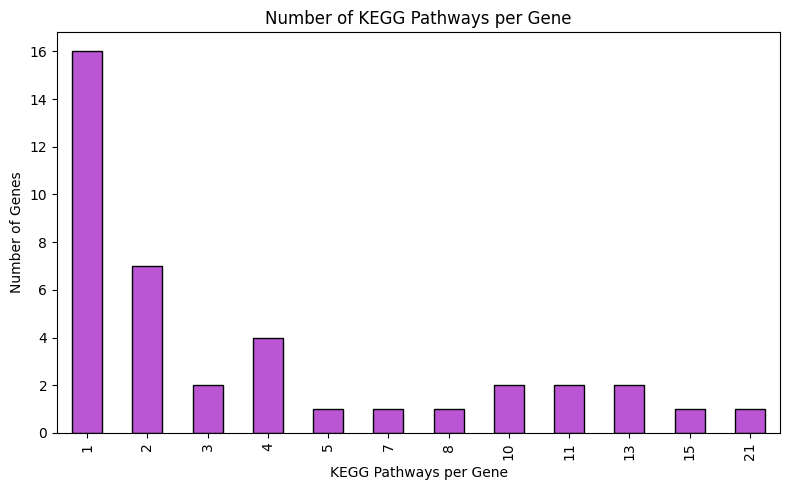

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Count how many genes have N pathways
kegg_counts = pd.Series([len(v) for v in shared_kegg_pathways.values()])
count_per_pathway = kegg_counts.value_counts().sort_index()

plt.figure(figsize=(8, 5))
count_per_pathway.plot(kind='bar', color='mediumorchid', edgecolor='black')
plt.title("Number of KEGG Pathways per Gene")
plt.xlabel("KEGG Pathways per Gene")
plt.ylabel("Number of Genes")
plt.tight_layout()
plt.show()
